# Sales Data

## 1. Exploratory Data Analysis
### 1.1 Data Shape & Structure Inspection
**Objectives:** - Iterate through daily folders within the `data/sales` directory to inspect the shape (rows and columns) of each `products.json` file.
- Aggregate all daily records into a single raw dataset (`df_raw`), appending a `recorded_date` column to track the timeline of each record.
- Evaluate the overall dimensions and list the available columns of the combined dataset to verify data completeness.

In [56]:
import os
import json
import pandas as pd
from IPython.display import display
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [57]:
data_dir = '../data/raw/sales'
all_dfs = []

print("--- DAILY DATA SHAPE ---")
# 1. Iterate through each daily folder to verify data dimensions
for folder in sorted(os.listdir(data_dir)):
    file_path = os.path.join(data_dir, folder, 'products.json')
    
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            df_daily = pd.DataFrame(json.load(f))
            print(f"{folder}: {df_daily.shape}")
            
            # Append source date as metadata and store in list for concatenation
            df_daily['recorded_date'] = folder
            all_dfs.append(df_daily)

# 2. Consolidate all daily snapshots into a single Master DataFrame
df_raw = pd.concat(all_dfs, ignore_index=True)

print("\n--- OVERALL RAW DATA ---")
print(f"Total Shape: {df_raw.shape} inluding 'recorded_date' column")
print(f"columns: {df_raw.columns.tolist()}")
display(df_raw)

--- DAILY DATA SHAPE ---
02-19-2026: (668, 12)
02-20-2026: (668, 12)
02-21-2026: (668, 12)
02-22-2026: (668, 12)
02-23-2026: (668, 12)
02-24-2026: (662, 12)
02-25-2026: (662, 12)
02-26-2026: (660, 12)
02-27-2026: (656, 12)
02-28-2026: (656, 12)
03-01-2026: (656, 12)
03-02-2026: (650, 12)
03-03-2026: (643, 12)
03-04-2026: (639, 12)
03-05-2026: (639, 12)
03-06-2026: (640, 12)
03-07-2026: (629, 12)
03-08-2026: (639, 12)
03-09-2026: (641, 12)
03-10-2026: (632, 12)
03-11-2026: (632, 12)
03-12-2026: (629, 12)
03-13-2026: (628, 12)
03-14-2026: (625, 12)
03-15-2026: (616, 12)
03-16-2026: (590, 12)
03-17-2026: (604, 12)
03-18-2026: (607, 12)
03-19-2026: (607, 12)
03-20-2026: (609, 12)

--- OVERALL RAW DATA ---
Total Shape: (19191, 13) inluding 'recorded_date' column
columns: ['id', 'ten_san_pham', 'danh_muc', 'gia_ban', 'gia_goc', 'so_luong_da_ban', 'diem_danh_gia', 'so_luot_nhan_xet', 'dia_diem_kho', 'ton_kho', 'thuong_hieu', 'link_san_pham', 'recorded_date']


,id,ten_san_pham,danh_muc,gia_ban,gia_goc,so_luong_da_ban,diem_danh_gia,so_luot_nhan_xet,dia_diem_kho,ton_kho,thuong_hieu,link_san_pham,recorded_date
0,2748113965,[VOUCHER 42% + MUA 2 GIẢM 5%] Giày Thể Thao Ni...,Giày chạy bộ nam,1789000,1789000,116,4.6571428571428575,35,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i2748113965...,02-19-2026
1,3133030071,[VOUCHER 42% + MUA 2 GIẢM 5%] Giày thể thao Ni...,Giày chạy bộ nam,1759000,1759000,37,5.0,12,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3133030071...,02-19-2026
2,3132909501,Giày thể thao Nike Revolution 8 Men's Road Run...,Giày chạy bộ nam,1909000,1909000,64,5.0,20,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3132909501...,02-19-2026
3,3102028052,[VOUCHER 40% + MUA 2 GIẢM 5%] Giày thể thao na...,Giày chạy bộ nam,1759000,1759000,96,4.7894736842105265,38,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3102028052...,02-19-2026
4,3101947457,[VOUCHER 42% + MUA 2 GIẢM 5%] Giày thể thao na...,Giày chạy bộ nam,2339000,2339000,14,5.0,7,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3101947457...,02-19-2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19186,3307939378,[VOUCHER ĐẾN 42% + MUA 2 GIẢM 3%] Giày thể tha...,Giày tập huấn luyện nam,3519000,3519000,5,,,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3307939378...,03-20-2026
19187,3307867807,[VOUCHER ĐẾN 42% + MUA 2 GIẢM 3%] Giày thể tha...,Giày tập huấn luyện nam,2189000,2189000,0,5.0,1,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3307867807...,03-20-2026
19188,2862895707,[VOUCHER ĐẾN 40% + MUA 2 GIẢM 3%] Giày Thể Tha...,Giày tập huấn luyện nam,1909000,1909000,71,4.619047619047619,21,Thành phố Hồ Chí Minh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i2862895707...,03-20-2026
19189,3104369249,[VOUCHER ĐẾN 42% + MUA 2 GIẢM 3%] Giày thể tha...,Giày tập huấn luyện nam,2069000,2069000,18,4.75,4,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3104369249...,03-20-2026


### 1.2 Missing Values Analysis

In [58]:
print("--- TRUE MISSING VALUES PER DAY (Nulls or Empty Strings) ---")

# 1. Define a function to identify "True Missing" (NaN or "")
def count_missing(df):
    # Check for Null values OR empty strings
    return ((df.isnull()) | (df == "")).sum()

# 2. Group by date and apply the custom missing check
missing_daily = df_raw.groupby('recorded_date').apply(count_missing)

# 3. Filter to show only columns that actually have missing data
missing_cols = missing_daily.loc[:, missing_daily.sum() > 0]

if not missing_cols.empty:
    display(missing_cols)
else:
    print("No Nulls or empty strings detected across all days.")

print("\n--- OVERALL TRUE MISSING SUMMARY ---")
# 4. Summarize the overall true missing values
true_missing_total = ((df_raw.isnull()) | (df_raw == "")).sum()
display(true_missing_total[true_missing_total > 0])

--- TRUE MISSING VALUES PER DAY (Nulls or Empty Strings) ---


,diem_danh_gia,so_luot_nhan_xet
recorded_date,,
02-19-2026,143,141
02-20-2026,143,141
02-21-2026,149,149
02-22-2026,149,149
02-23-2026,149,149
02-24-2026,147,147
02-25-2026,147,147
02-26-2026,146,146
02-27-2026,144,144



--- OVERALL TRUE MISSING SUMMARY ---


diem_danh_gia       3547
so_luot_nhan_xet    3510
dtype: int64

**Observation: Why is there a discrepancy between Missing Values?**

While both columns often share missing values, a discrepancy (e.g., 3559 vs 3522) occurs due to the following:

**1. 0 Reviews vs. Null Stars**
A product can have "0 reviews" (a valid recorded count), but the Rating Score remains `Null`. This is because:
- **Mathematical Logic:** It is impossible to calculate an average rating if there are zero reviews.
- **UI Logic:** Platforms often show "0 reviews" text but omit the star rating entirely to avoid showing a misleading "0.0 stars" for a new product.

**2. Hidden Missing Data (Empty Strings "")**
In some cases, the "Review Count" is an empty text string `""` or a placeholder (like "-") while the "Rating Score" is a formal `Null` object. Our updated check captures both to ensure no "ghost data" is missed during cleaning.

**Proposal Plan:**
- **`so_luot_nhan_xet` (Review Count):** Fill all `NaN` and `""` with `0` (Zero feedback).
- **`diem_danh_gia` (Rating Score):** Keep as `NaN` (Unrated). Converting these to `0.0` would incorrectly flag them as "Bad Products" instead of "New Products."

### 1.3 Data Type & Categorical Inspection

In [59]:
print("--- DATA TYPES OVERVIEW ---")
# 1. Print the data type of each column
display(pd.DataFrame(df_raw.dtypes, columns=['Data Type']))

--- DATA TYPES OVERVIEW ---


,Data Type
id,object
ten_san_pham,str
danh_muc,str
gia_ban,object
gia_goc,object
so_luong_da_ban,int64
diem_danh_gia,str
so_luot_nhan_xet,str
dia_diem_kho,str
ton_kho,str


In [60]:
# 1. Define the categorical columns to inspect
categorical_cols = ['thuong_hieu', 'danh_muc', 'ton_kho', 'dia_diem_kho']

# 2. Loop through and list unique names only
for col in categorical_cols:
    if col in df_raw.columns:
        # Get unique values, drop NaNs for a cleaner list
        unique_vals = df_raw[col].dropna().unique()
        unique_len = len(unique_vals)
        
        print(f"\n COLUMN: '{col}' ({unique_len} unique values found)")
        print(f"   Values: {sorted(list(unique_vals))}") # Sorted for easier manual spotting of typos
    else:
        print(f"\n WARNING: Column '{col}' not found.")


 COLUMN: 'thuong_hieu' (2 unique values found)
   Values: ['Jordan', 'Nike']

 COLUMN: 'danh_muc' (21 unique values found)
   Values: ['Dép xỏ ngón', 'Giày chạy bộ bé trai', 'Giày chạy bộ nam', 'Giày chạy bộ nữ', 'Giày sneaker nam', 'Giày sneaker nữ', 'Giày thể thao', 'Giày thể thao bé trai', 'Giày tập huấn luyện nam', 'Giày tập huấn luyện nữ', 'Quần Short thể thao nam', 'Quần Short thể thao nữ', 'Quần dài thể thao nam', 'Quần dài thể thao nữ', 'Túi thể thao', 'Tất, Găng tay thể thao và đồ bảo hộ', 'Áo lót thể thao nữ', 'Áo phông & Áo ba lỗ', 'Áo thun thể thao bé gái', 'Áo thun thể thao nam', 'Áo thun thể thao nữ']

 COLUMN: 'ton_kho' (2 unique values found)
   Values: ['Còn hàng', 'Hết hàng']

 COLUMN: 'dia_diem_kho' (4 unique values found)
   Values: ['Hà Nội', 'Hồ Chí Minh', 'Thành phố Hồ Chí Minh', 'Tây Ninh']


**Observation: Data Type Diagnosis**

**1. The Good (Correct Types):**
- `so_luong_da_ban` was successfully parsed as `int64`. This is excellent and indicates clean raw formatting for cumulative sales.
- Categorical and descriptive fields (`id`, `ten_san_pham`, `danh_muc`, `thuong_hieu`) are correctly formatted as `str`. Keeping `id` as a string is a best practice to prevent the loss of leading zeros and ensure safe table joins later.

**2. The Problematic (Requires Type Casting):**
The following columns contain numerical data but are currently interpreted as plain text (`str`).
- **Pricing Data:** `gia_ban`, `gia_goc` -> Must be converted to `float`.
- **Review Data:** `diem_danh_gia`, `so_luot_nhan_xet` -> Must be converted to `float` (to accommodate `NaN` values correctly).

**3. The Categorical Findings:**
- **Data Integrity Issue (Location Standardization):** * The "**Hồ Chí Minh**" Split: A critical naming inconsistency was detected between "**Thành phố Hồ Chí Minh**" and "**Hồ Chí Minh**". These refer to the same geographical entity and must be merged during preprocessing to ensure accurate regional analysis on the dashboard.

### 1.4 Duplicates Detection
**Objectives:** 
- Group data by `recorded_date` to check if the same product `id` was scraped multiple times on the same day.
- Display the duplicate count for **every single day** to ensure absolute transparency of the dataset's health.

In [61]:
print("--- DUPLICATES PER DAY ---")

# 1. Group by date and count duplicated IDs within each day
daily_duplicates = df_raw.groupby('recorded_date').apply(lambda x: x.duplicated(subset=['id']).sum())

# 2. Format as a nice DataFrame for display (Showing ALL days)
df_dups_display = daily_duplicates.reset_index()
df_dups_display.columns = ['Recorded Date', 'Duplicate Count']

# Display the full table
display(df_dups_display)
    
# 3. Summary and Action Plan
total_dups = daily_duplicates.sum()
print(f"\nTotal duplicate rows across all days: {total_dups:,}")

--- DUPLICATES PER DAY ---


,Recorded Date,Duplicate Count
0,02-19-2026,0
1,02-20-2026,0
2,02-21-2026,0
3,02-22-2026,0
4,02-23-2026,0
5,02-24-2026,0
6,02-25-2026,0
7,02-26-2026,0
8,02-27-2026,0
9,02-28-2026,0



Total duplicate rows across all days: 0


### Conclusion: Exploratory Data Analysis (EDA) Summary

Based on the data profiling steps conducted above, the raw dataset provides a solid foundation but exhibits typical artifacts of web-scraped JSON data. Before we can extract reliable business insights, we must address the following "technical debt" in the Preprocessing phase:

**1. Data Type Conversion (Critical Priority):** Mathematical operations cannot be performed on text. We must cast financial columns (`gia_ban`, `gia_goc`) and review metrics (`diem_danh_gia`, `so_luot_nhan_xet`) from `String` to `Float/Integer`.

**2. Missing Values Treatment (Logical Imputation):**
We observed missing data across the rating and review columns, including both formal `Null` objects and hidden empty strings (`""`). The slight discrepancy in their counts occurs because e-commerce platforms often explicitly display "0 reviews" while omitting the star rating UI entirely. 

To resolve this logically:
- **`so_luot_nhan_xet` (Review Count):** We will coerce all invalid formats to missing values, then impute them with `0` (indicating zero customer feedback) and cast as integers.
- **`diem_danh_gia` (Rating Score):** We will strictly retain these as `NaN` (Unrated). Converting them to `0.0` would incorrectly classify new/unrated items as "poor quality" and artificially crash the brand's overall average rating.

**3. Data Deduplication:**
Validation confirmed that the crawler worked perfectly. There are 0 duplicate records within any single day.

**4. Feature Engineering (The Cumulative Problem):**  
Since `so_luong_da_ban` is a historical cumulative number, we need to design a **Max-Tracking Algorithm** to calculate the actual `daily_sales` and `daily_revenue`, while handling API glitches where the cumulative number suddenly drops to zero.

## 2. Data Preprocessing

### 2.1 Data Cleaning & Type Casting
**Objectives:** 
- Standardize Product Names: Strip dynamic promotional tags (e.g., [VOUCHER...]) from the beginning of the `ten_san_pham` column
- Handle the Missing Values: Fill `so_luot_nhan_xet` with `0` while keeping `diem_danh_gia` as `NaN`.
- Cast financial and metric columns from text (`String`) to strictly numeric formats (`Float`/`Integer`) so we can perform mathematical calculations.
- Resolve naming inconsistencies in the `dia_diem_kho` column, specifically merging "**Hồ Chí Minh**" into the standardized "**Thành phố Hồ Chí Minh**" for accurate regional analysis.

In [62]:
# 1. Path Configuration
RAW_SALES_DIR = '../data/raw/sales'
PROCESSED_SALES_DIR = '../data/processed/sales'

# 2. Simplified Cleaning Logic
def clean_sales_data(df):
    # Standardize product names by removing any leading tags in square brackets
    if 'ten_san_pham' in df.columns:
        df['ten_san_pham'] = df['ten_san_pham'].apply(lambda x: re.sub(r'^\[.*?\]\s*', '', str(x)).strip())
    
    # Focus on financial and review metrics
    numeric_cols = list({'gia_ban', 'gia_goc', 'diem_danh_gia', 'so_luot_nhan_xet'} & set(df.columns))
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
    # Logic Fixes
    df['so_luot_nhan_xet'] = df['so_luot_nhan_xet'].fillna(0).astype(int)
    df['dia_diem_kho'] = df['dia_diem_kho'].replace('Hồ Chí Minh', 'Thành phố Hồ Chí Minh')
    return df

# 3. Direct Folder-by-Folder Execution
for day_folder in os.listdir(RAW_SALES_DIR):
    # Define source and destination
    src_dir = os.path.join(RAW_SALES_DIR, day_folder)
    dest_dir = os.path.join(PROCESSED_SALES_DIR, day_folder)
    
    # Create target folder
    os.makedirs(dest_dir, exist_ok=True)
    
    # --- Process CSV ---
    df_csv = pd.read_csv(os.path.join(src_dir, 'products.csv'))
    clean_sales_data(df_csv).to_csv(os.path.join(dest_dir, 'products.csv'), index=False, encoding='utf-8-sig')
    
    # --- Process JSON ---
    df_json = pd.read_json(os.path.join(src_dir, 'products.json'))
    clean_sales_data(df_json).to_json(os.path.join(dest_dir, 'products.json'), orient='records', force_ascii=False, indent=4)
    
    # Success Message
    print(f"Successfully processed and updated: sales/{day_folder}")

Successfully processed and updated: sales/02-19-2026
Successfully processed and updated: sales/02-20-2026
Successfully processed and updated: sales/02-21-2026
Successfully processed and updated: sales/02-22-2026
Successfully processed and updated: sales/02-23-2026
Successfully processed and updated: sales/02-24-2026
Successfully processed and updated: sales/02-25-2026
Successfully processed and updated: sales/02-26-2026
Successfully processed and updated: sales/02-27-2026
Successfully processed and updated: sales/02-28-2026
Successfully processed and updated: sales/03-01-2026
Successfully processed and updated: sales/03-02-2026
Successfully processed and updated: sales/03-03-2026
Successfully processed and updated: sales/03-04-2026
Successfully processed and updated: sales/03-05-2026
Successfully processed and updated: sales/03-06-2026
Successfully processed and updated: sales/03-07-2026
Successfully processed and updated: sales/03-08-2026
Successfully processed and updated: sales/03-0

### 2.2 Data Consolidation & Quality Validation After Cleaning

Load processed data

In [63]:
data_dir = '../data/processed/sales'
all_dfs = []

# 1. Iterate through each daily folder to verify data dimensions
for folder in sorted(os.listdir(data_dir)):
    file_path = os.path.join(data_dir, folder, 'products.json')
    
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            df_daily = pd.DataFrame(json.load(f))
            
            # Append source date as metadata and store in list for concatenation
            df_daily['recorded_date'] = folder
            all_dfs.append(df_daily)

# 2. Consolidate all daily snapshots into a single Master DataFrame
df_processed = pd.concat(all_dfs, ignore_index=True)
display(df_processed.head())

,id,ten_san_pham,danh_muc,gia_ban,gia_goc,so_luong_da_ban,diem_danh_gia,so_luot_nhan_xet,dia_diem_kho,ton_kho,thuong_hieu,link_san_pham,recorded_date
0,2748113965,Giày Thể Thao Nike Men's Revolution 7 Road Run...,Giày chạy bộ nam,1789000,1789000,116,4.657143,35,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i2748113965...,02-19-2026
1,3133030071,Giày thể thao Nike Run Defy Men's Road Running...,Giày chạy bộ nam,1759000,1759000,37,5.000000,12,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3133030071...,02-19-2026
2,3132909501,Giày thể thao Nike Revolution 8 Men's Road Run...,Giày chạy bộ nam,1909000,1909000,64,5.000000,20,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3132909501...,02-19-2026
3,3102028052,Giày thể thao nam Road Running Nike Run Defy -...,Giày chạy bộ nam,1759000,1759000,96,4.789474,38,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3102028052...,02-19-2026
4,3101947457,Giày thể thao nam Road Running Nike Interact R...,Giày chạy bộ nam,2339000,2339000,14,5.000000,7,Tây Ninh,Còn hàng,Nike,https://www.lazada.vn/products/pdp-i3101947457...,02-19-2026


In [64]:
# Validation Summary
print("--- DATA VALIDATION REPORT ---")
df_processed.info()

# Numeric Check
print("\n[1] Numeric Stats:")
display(df_processed[['gia_ban', 'gia_goc', 'diem_danh_gia', 'so_luot_nhan_xet']].describe())

# Categorical Check
unique_locs = df_processed['dia_diem_kho'].unique()
print(f"\n[2] dia_diem_kho: {unique_locs}")

# Missing Values Report
print("\n[3] Missing Values Count:")
print(df_processed[['diem_danh_gia', 'so_luot_nhan_xet']].isna().sum())

--- DATA VALIDATION REPORT ---
<class 'pandas.DataFrame'>
RangeIndex: 19191 entries, 0 to 19190
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                19191 non-null  int64  
 1   ten_san_pham      19191 non-null  str    
 2   danh_muc          19191 non-null  str    
 3   gia_ban           19191 non-null  int64  
 4   gia_goc           19191 non-null  int64  
 5   so_luong_da_ban   19191 non-null  int64  
 6   diem_danh_gia     15644 non-null  float64
 7   so_luot_nhan_xet  19191 non-null  int64  
 8   dia_diem_kho      19191 non-null  str    
 9   ton_kho           19191 non-null  str    
 10  thuong_hieu       19191 non-null  str    
 11  link_san_pham     19191 non-null  str    
 12  recorded_date     19191 non-null  str    
dtypes: float64(1), int64(5), str(7)
memory usage: 5.1 MB

[1] Numeric Stats:


,gia_ban,gia_goc,diem_danh_gia,so_luot_nhan_xet
count,1.919100e+04,1.919100e+04,15644.000000,19191.000000
mean,2.039077e+06,2.043885e+06,4.776601,9.555990
std,1.040334e+06,1.042517e+06,0.452491,13.650402
min,3.090000e+05,3.090000e+05,1.000000,0.000000
25%,1.119000e+06,1.119000e+06,4.714286,1.000000
50%,2.069000e+06,2.069000e+06,5.000000,6.000000
75%,2.649000e+06,2.649000e+06,5.000000,13.000000
max,6.179000e+06,6.179000e+06,5.000000,160.000000



[2] dia_diem_kho: <ArrowStringArray>
['Tây Ninh', 'Thành phố Hồ Chí Minh', 'Hà Nội']
Length: 3, dtype: str

[3] Missing Values Count:
diem_danh_gia       3547
so_luot_nhan_xet       0
dtype: int64


### 2.3 Feature Engineering

**Objectives**
This step performs a critical transformation: converting **cumulative static data** (total sold over time) into **daily dynamic metrics**. 

Unlike basic analysis, this process synchronizes the calculated results directly back into the source files (**JSON** and **CSV**) for each specific date, creating a ready-to-use dataset.

**1. The Maximum-Tracking Algorithm**  
The core of this logic is the `max_sold_tracker` dictionary. This acts as a **persistent memory** for each product ID to ensure accuracy across multiple days.

**Key Functions:**
* **Persistent Tracking:** Records the highest `so_luong_da_ban` (Total Sold) ever observed for each product.
* **Glitch Resistance:** In web scraping, "Total Sold" values may decrease due to platform resets or crawling errors. By tracking the maximum value, we:
    * Prevent negative sales.
    * Ensure only real growth is counted.


**2. Calculation Logic & Formulas**

**Baseline Date (`02-19-2026`):**
This is considered **Day 0**. Since there is no previous data to compare against, daily sales are initialized to zero:
$$\text{so\_luong\_ban\_trong\_ngay} = 0$$

**Daily Sales Formula:**
For all subsequent dates, the incremental sales are calculated by subtracting the historical maximum from the current total:
$$\text{so\_luong\_ban\_trong\_ngay} = \max(0, \text{so\_luong\_da\_ban} - \text{max\_so\_luong\_da\_ban})$$

**Daily Revenue Formula:**
Revenue is dynamically calculated based on the generated daily sales and the current price:
$$\text{doanh\_thu\_ngay} = \text{so\_luong\_ban\_trong\_ngay} \times \text{gia\_ban}$$

In [65]:

DATA_DIR = '../data/processed/sales'
BASELINE_DATE = '02-19-2026' # The starting point for tracking

def run_sales_analysis_v3():
    # 1. Collect and filter folders with mm-dd-yyyy format
    folders = []
    for f in os.listdir(DATA_DIR):
        if os.path.isdir(os.path.join(DATA_DIR, f)):
            try:
                datetime.strptime(f, '%m-%d-%Y') 
                folders.append(f)
            except ValueError:
                continue

    # 2. Sort folders chronologically
    sorted_folders = sorted(folders, key=lambda x: datetime.strptime(x, '%m-%d-%Y'))

    # 3. Tracker for the MAXIMUM cumulative sales recorded per product ID
    max_sold_tracker = {}

    print(f"Starting feature engineering for {len(sorted_folders)} days...")

    for folder in sorted_folders:
        json_path = os.path.join(DATA_DIR, folder, 'products.json')
        csv_path = os.path.join(DATA_DIR, folder, 'products.csv')

        if not os.path.exists(json_path): continue

        with open(json_path, 'r', encoding='utf-8') as f:
            products = json.load(f)

        updated_list = []
        for p in products:
            p_id = str(p.get('id')).strip()
            
            # Safe casting for numeric fields
            try:
                curr_total = int(float(p.get('so_luong_da_ban', 0)))
                price = float(p.get('gia_ban', 0))
            except:
                curr_total, price = 0, 0.0
                
            max_so_far = max_sold_tracker.get(p_id, 0)

            # Calculation Logic
            if folder == BASELINE_DATE:
                daily_sales = 0
                max_sold_tracker[p_id] = curr_total # Set the baseline
            else:
                if curr_total > max_so_far:
                    daily_sales = curr_total - max_so_far
                    max_sold_tracker[p_id] = curr_total # Update new maximum
                else:
                    daily_sales = 0 # Handle data resets or no sales

            # Append new metrics to product dictionary
            p['so_luong_ban_trong_ngay'] = daily_sales
            p['doanh_thu_ngay'] = daily_sales * price
            updated_list.append(p)

        # 4. Save/Overwrite JSON and CSV files
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(updated_list, f, ensure_ascii=False, indent=4)
        
        pd.DataFrame(updated_list).to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f"Successfully processed and updated: {folder}")

if __name__ == "__main__":
    run_sales_analysis_v3()

Starting feature engineering for 30 days...
Successfully processed and updated: 02-19-2026
Successfully processed and updated: 02-20-2026
Successfully processed and updated: 02-21-2026
Successfully processed and updated: 02-22-2026
Successfully processed and updated: 02-23-2026
Successfully processed and updated: 02-24-2026
Successfully processed and updated: 02-25-2026
Successfully processed and updated: 02-26-2026
Successfully processed and updated: 02-27-2026
Successfully processed and updated: 02-28-2026
Successfully processed and updated: 03-01-2026
Successfully processed and updated: 03-02-2026
Successfully processed and updated: 03-03-2026
Successfully processed and updated: 03-04-2026
Successfully processed and updated: 03-05-2026
Successfully processed and updated: 03-06-2026
Successfully processed and updated: 03-07-2026
Successfully processed and updated: 03-08-2026
Successfully processed and updated: 03-09-2026
Successfully processed and updated: 03-10-2026
Successfully pro

### 2.4 Time-Series & Trend Analysis After Feature Engineering

Load processed data again

In [66]:
data_dir = '../data/processed/sales'
all_dfs = []

# 1. Iterate through each daily folder to verify data dimensions
for folder in sorted(os.listdir(data_dir)):
    file_path = os.path.join(data_dir, folder, 'products.json')
    
    if os.path.isfile(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            df_daily = pd.DataFrame(json.load(f))
            
            # Append source date as metadata and store in list for concatenation
            df_daily['recorded_date'] = folder
            all_dfs.append(df_daily)

# 2. Consolidate all daily snapshots into a single Master DataFrame
df_processed = pd.concat(all_dfs, ignore_index=True)

--- TIME-SERIES & TREND ANALYSIS ---


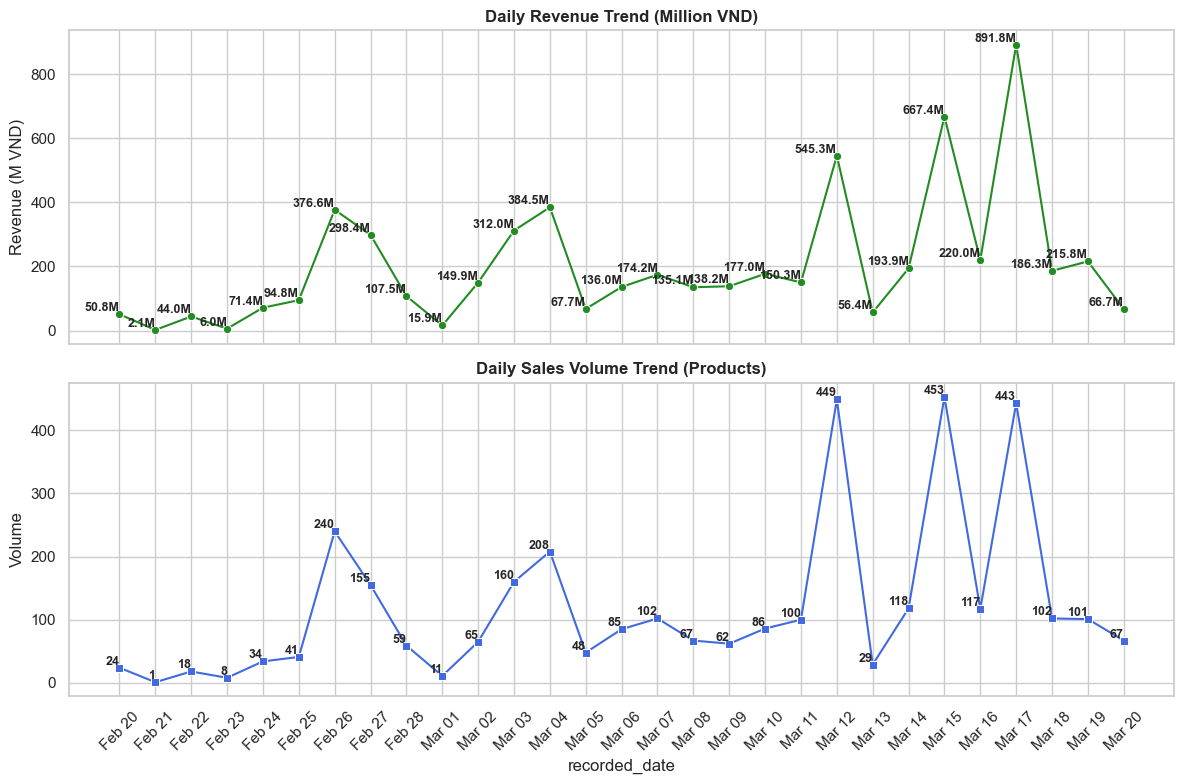

In [67]:
print("--- TIME-SERIES & TREND ANALYSIS ---")

# 1. Aggregate daily data
df_trend = df_processed.groupby('recorded_date')[['doanh_thu_ngay', 'so_luong_ban_trong_ngay']].sum().reset_index()
df_trend['recorded_date'] = pd.to_datetime(df_trend['recorded_date'])

# 3. Remove 02-19-2026 (Baseline)
df_trend = df_trend[df_trend['recorded_date'] != '2026-02-19']

# 4. Convert Revenue to Millions
df_trend['doanh_thu_ngay'] = df_trend['doanh_thu_ngay'] / 1_000_000

# 5. Initialize Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
sns.set_theme(style="whitegrid")

# --- Plot 1: Daily Revenue ---
sns.lineplot(data=df_trend, x='recorded_date', y='doanh_thu_ngay', marker='o', color='forestgreen', ax=ax1)
ax1.set_title('Daily Revenue Trend (Million VND)', fontweight='bold')
ax1.set_ylabel('Revenue (M VND)')

# --- Plot 2: Daily Sales Volume ---
sns.lineplot(data=df_trend, x='recorded_date', y='so_luong_ban_trong_ngay', marker='s', color='royalblue', ax=ax2)
ax2.set_title('Daily Sales Volume Trend (Products)', fontweight='bold')
ax2.set_ylabel('Volume')

# 6. Add Data Labels
for _, row in df_trend.iterrows():
    ax1.text(row['recorded_date'], row['doanh_thu_ngay'], f"{row['doanh_thu_ngay']:,.1f}M", 
             ha='right', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(row['recorded_date'], row['so_luong_ban_trong_ngay'], f"{int(row['so_luong_ban_trong_ngay'])}", 
             ha='right', va='bottom', fontsize=9, fontweight='bold')

# 7. Final Formatting
plt.xticks(df_trend['recorded_date'], df_trend['recorded_date'].dt.strftime('%b %d'), rotation=45)
plt.tight_layout()
plt.show()

# Reviews Data

## Exploratory Data Analysis
### Data Shape & Structure Inspection

In [68]:
review_path = '../data/raw/reviews/all_reviews.json'
df_rv = pd.read_json(review_path)

print("\n--- OVERALL RAW DATA ---")
print(f"Total Shape: {df_rv.shape[0]} rows, {df_rv.shape[1]} columns")
print(f"columns: {df_rv.columns.tolist()}")
display(df_rv)


--- OVERALL RAW DATA ---
Total Shape: 7605 rows, 4 columns
columns: ['id_sp', 'rating', 'comment', 'time']


,id_sp,rating,comment,time
0,3307837949,5,"Hàng đẹp! Shop uy tín, sẽ mua tiếp những sản p...",2026-02-28
1,2748113965,5,"Đa năng cho các hoạt động khác nhau, Nhẹ và th...",2025-01-12
2,2748113965,1,Tôi mua 1 đôi nam và 1 đôi nữ. Đôi nữ ổn nhưng...,2024-10-15
3,2748113965,5,"Nhẹ và thoáng khí, Kết cấu bền bỉ, Thiết kế mư...",2025-01-01
4,2748113965,4,Giày mới mà đã bị ố vàng. Giá tốt nên chấp nhậ...,2025-12-17
...,...,...,...,...
7600,3133020204,5,,2026-03-07
7601,3308955438,1,Chính sách đổi trả tuy ghi rõ 30 ngày miễn phí...,2026-03-14
7602,2994723495,5,,2026-03-14
7603,2994670490,5,"Quần tốt, 1m72 80kg size L vừa, quần ống rộng ...",2026-03-07


### Missing Value Analysis

In [69]:
missing_count = df_rv.isna().sum()
missing_percentage = (df_rv.isna().sum() / len(df_rv)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage.map('{:.2f}%'.format)
})

print("--- MISSING VALUE REPORT ---")
display(missing_report)


--- MISSING VALUE REPORT ---


,Missing Values,Percentage (%)
id_sp,0,0.00%
rating,0,0.00%
comment,0,0.00%
time,0,0.00%


### Data Type & Categorical Inspection

In [70]:
df_rv.info()

<class 'pandas.DataFrame'>
RangeIndex: 7605 entries, 0 to 7604
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id_sp    7605 non-null   int64
 1   rating   7605 non-null   int64
 2   comment  7605 non-null   str  
 3   time     7605 non-null   str  
dtypes: int64(2), str(2)
memory usage: 680.0 KB


### Duplicates Detection

In [71]:
print(f"The number of duplicated reviews: {df_rv.duplicated().sum()}")

The number of duplicated reviews: 0


### Numerical Variable Distribution

--- RATING DESCRIPTIVE STATISTICS ---
count    7605.000000
mean        4.766206
std         0.875338
min         1.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64


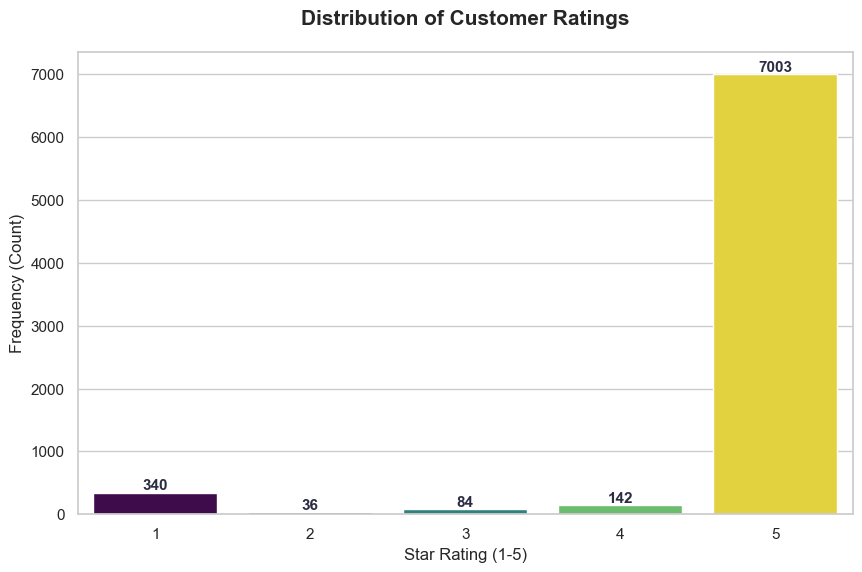

In [72]:
# 1. Calculate basic descriptive statistics
rating_stats = df_rv['rating'].describe()
print("--- RATING DESCRIPTIVE STATISTICS ---")
print(rating_stats)

# 2. Visualization: Rating Frequency (Count Plot)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the count plot
ax = sns.countplot(data=df_rv, x='rating', palette='viridis', hue='rating', legend=False)

# 3. Add Data Labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11, color='#2b2d42')

# 4. Final Formatting
plt.title('Distribution of Customer Ratings', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Star Rating (1-5)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

plt.show()

### Comment Time Analysis

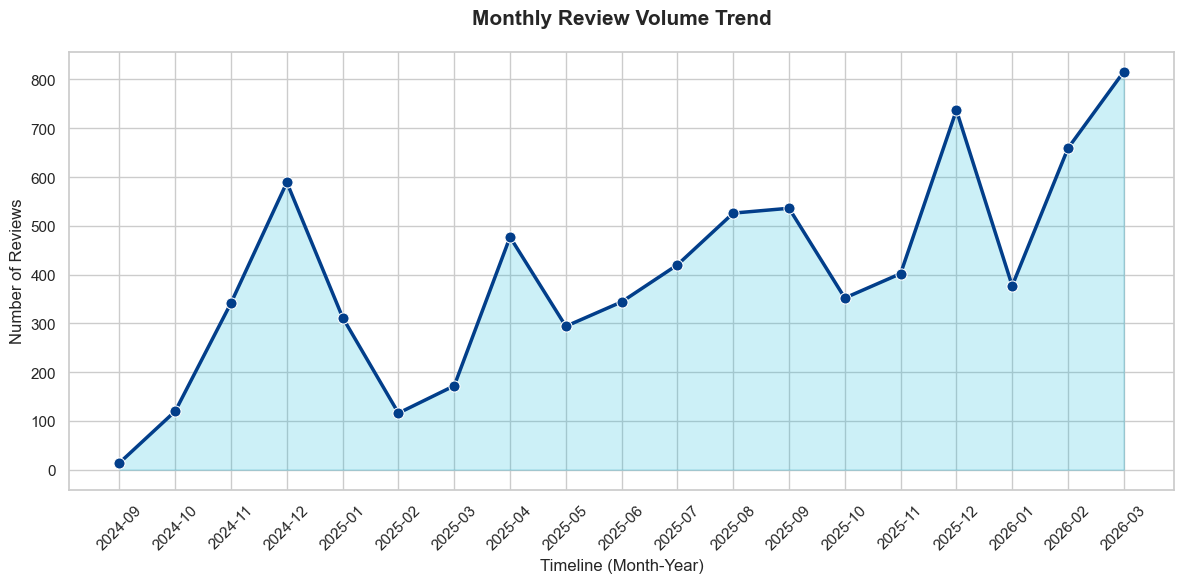

In [73]:
# 1. Ensure 'time' is in datetime format
df_rv['time'] = pd.to_datetime(df_rv['time'])

# 2. Resample or Group by Month
# Creating a 'Year-Month' period for grouping
df_rv['month_year'] = df_rv['time'].dt.to_period('M').astype(str)
monthly_counts = df_rv.groupby('month_year').size().reset_index(name='review_count')

# 3. Visualization: Time Series Line Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plotting the trend line
sns.lineplot(data=monthly_counts, x='month_year', y='review_count', 
             marker='o', markersize=8, color='#023e8a', linewidth=2.5)

# Adding a subtle fill for aesthetic clarity
plt.fill_between(monthly_counts['month_year'], monthly_counts['review_count'], color='#00b4d8', alpha=0.2)

# 4. Formatting the chart
plt.title('Monthly Review Volume Trend', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Timeline (Month-Year)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for better readability

plt.tight_layout()
plt.show()

### Conclusion: 
**1. Data Integrity & Quality**
- **Completeness**: No missing values (nulls) detected across any columns.
- **Uniqueness**: No duplicate records found; every entry represents a unique customer interaction.

**2. Numerical Insights (Rating Distribution)**
- **Dominant Sentiment**: 5-star reviews account for 92.1% (7,003 out of 7,605) of total feedback.
- **Minority Ratings**: Lower ratings are rare, with 4-star (142), 3-star (84), and 2-star (36) reviews making up a small fraction.
- **Critical Feedback**: There is a minor cluster of 1-star reviews (340). These represent the primary "pain points" that require further qualitative text analysis to identify specific product or service issues.

**3. Temporal Insights (Growth Trend)**
- **Increasing Momentum**: The review volume shows a consistent upward trend over time.
- **Business Growth**: The rising number of comments suggests increasing sales velocity and higher customer engagement as the shop matures.